In [1]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

In [2]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="What to cover")

In [3]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [4]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str

In [6]:
from dotenv import load_dotenv
load_dotenv()
llm = ChatGroq(model="openai/gpt-oss-120b")

In [7]:
def orchestrator(state: State) -> dict:

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}

In [8]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [9]:
def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [10]:
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}


In [11]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

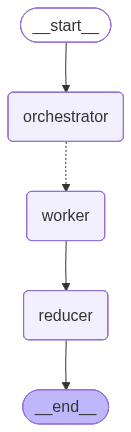

In [12]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [13]:
out = app.invoke({"topic": "Write a blog on Generative AI", "sections": []})

In [14]:
out

{'topic': 'Write a blog on Generative AI',
 'plan': Plan(blog_title='Generative AI: Transforming Creativity and Innovation', tasks=[Task(id=1, title='Introduction to Generative AI', brief="Define generative AI, its core concepts, and why it matters in today's tech landscape."), Task(id=2, title='How Generative Models Work', brief='Explain the underlying technologies (GANs, VAEs, diffusion models, LLMs) in an accessible way.'), Task(id=3, title='Key Applications Across Industries', brief='Showcase real‑world use cases: content creation, design, drug discovery, coding, and more.'), Task(id=4, title='Benefits and Opportunities', brief='Discuss productivity gains, democratization of creativity, and new business models enabled by generative AI.'), Task(id=5, title='Challenges, Risks, and Ethical Considerations', brief='Cover bias, copyright, misinformation, resource consumption, and responsible AI practices.'), Task(id=6, title='Getting Started: Tools and Resources', brief='Curated list of 